# Tomato Disease Detection using Machine Learning
### Feature Engineering, Tree-Based Models (Random Forest & XGBoost), and Error Analysis

## 1. Introduction & Project Overview
This project aims to develop a robust and interpretable Machine Learning pipeline to classify **10 different classes of tomato diseases and healthy leaves**. 

We extract meaningful statistical representations of **Color** and **Texture** to train high-performance gradient-boosted and ensemble tree models.

### Dataset
The project utilizes the **New Plant Diseases Dataset**, which contains augmented, high-resolution images of plant leaves captured under controlled laboratory environments.

### Machine Learning Pipeline Overview
1. **Data Ingestion & Filtering:** Isolating the 10 tomato-specific classes from the broader dataset.
2. **Feature Extraction:** Building a custom tabular dataset based on Color Moments (RGB/HSV) and Texture (GLCM).
3. **Baseline Modeling:** Training a Random Forest classifier with Hyperparameter Tuning (Grid Search).
4. **Advanced Modeling:** Boosting performance using XGBoost.
5. **Unsupervised Experimentation:** Evaluating Cluster Distance Features via K-Means.
6. **Diagnostic Analysis:** Multi-class Confusion Matrix evaluation and Outlier/Bias detection.

## 2. Data Ingestion & Class Filtering
Before extracting features, we map the directory structure and filter out non-tomato crops. The code below targets the `train` directory, identifies all subfolders representing tomato leaves, and lists the 10 specific target classes (9 diseases and 1 healthy control group).

In [1]:
# =========== Make dataframe from train folder ====================

import numpy as np 
import pandas as pd 
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub

try:
    # If running inside Kaggle's environment
    base_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
    if not os.path.exists(base_path):
        raise FileNotFoundError
except (FileNotFoundError, Exception):
    # Remote download if running outside Kaggle (e.g., Local PC / Colab)
    print("Running outside Kaggle environment. Downloading dataset via kagglehub...")
    download_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    base_path = os.path.join(download_path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)")

train_path = os.path.join(base_path, "train")
all_classes = os.listdir(train_path)
tomato_classes = [c for c in all_classes if c.startswith("Tomato")]
print(f"Found {len(tomato_classes)} tomato disease classes:")
for disease_class in tomato_classes:
    print(disease_class)



Found 10 tomato disease classes:
Tomato___Late_blight
Tomato___healthy
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_spider_mite


## 3. Exploratory Data Inspection & Sanity Check
Before processing the entire dataset, we load a single sample image to verify our pipeline. This step ensures that:
1. Image paths are correctly generated.
2. OpenCV successfully loads the image files.
3. We inspect the dimensions of the sample to confirm it aligns with the dataset's documentation (which specifies a uniform $256 \times 256$ resolution). Standardized dimensions are critical for texture analysis (GLCM), ensuring we don't introduce distortion through resizing.

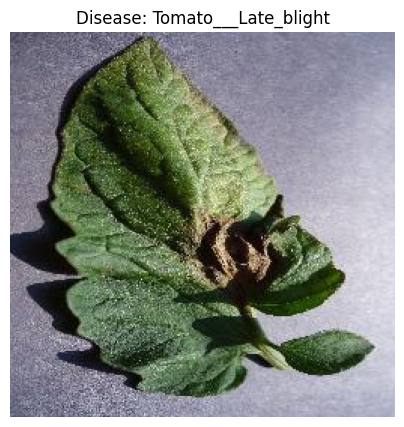

Image dimensions (Height, Width, RGB Channels): (256, 256, 3)


In [2]:
import cv2
import matplotlib.pyplot as plt

sample_class = tomato_classes[0] 
sample_dir = os.path.join(train_path, sample_class)

sample_image_name = os.listdir(sample_dir)[0]
sample_image_path = os.path.join(sample_dir, sample_image_name)

#print(sample_image_path)

img_bgr = cv2.imread(sample_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Disease: {sample_class}")
plt.axis('off')
plt.show()

print("Image dimensions (Height, Width, RGB Channels):", img_rgb.shape)

## 4. Feature Engineering Pipeline (Color Moments & GLCM Texture)
To transform raw pixel data into structured, interpretable features for our tree-based classifiers, we implement a custom feature extraction pipeline. Instead of relying on raw pixels, we capture the symptoms of leaf diseases using two primary domains: **Color Distribution** and **Spatial Surface Texture**.

### A. Color Characteristics (Statistical Moments)
Diseases alter the chemical composition of the leaf, causing visual symptoms like necrosis (browning) or chlorosis (yellowing). We capture this mathematically using:
* **Green Channel (Mean/Std):** Monitors the breakdown of chlorophyll (loss of green indicates chlorosis/disease).
* **Red Channel (Mean/Std):** Captures necrotic lesions, brown spots, and yellowing components.
* **Hue & Saturation (HSV Space):** HSV isolates pure color information (Hue) from its intensity. A high standard deviation in Hue (`std_hue`) mathematically represents a "mottled" leaf with mixed green and yellow/brown spots, while `mean_saturation` detects the color vividness (diseased/wilted tissues look washed out).

### B. Texture Analysis via GLCM
Leaf spots, molds, and fungal webs change the physical smoothness of the leaf surface. We utilize the **Gray-Level Co-occurrence Matrix (GLCM)** computed across 4 spatial orientations ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) to extract structural properties:
* **Contrast:** Measures the local intensity variations. High contrast indicates sharp boundaries, such as the distinct edges of fungal leaf spots (*Target Spot*, *Septoria*).
* **Homogeneity:** Measures the smoothness of the image. Healthy leaves exhibit high homogeneity, while infected, rough, or torn tissues cause a sharp drop in this metric.

*Engineering Note:* Images are resized to $128 \times 128$ to significantly optimize computation speed during batch processing while retaining the spatial resolution necessary for texture analysis.

In [3]:
from skimage.feature import graycomatrix, graycoprops

def extract_features_from_image(image_path):
    
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None 
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_normalized = img_resized / 255.0

    # --- A. Color Characteristics (RGB and HSV) ---

    # Mean and Std for Green (important for chlorosis) and Red (participates in Yellow and Brown[necrosis])
    mean_G = np.mean(img_normalized[:, :, 1])
    std_G = np.std(img_normalized[:, :, 1])
    mean_R = np.mean(img_normalized[:, :, 0])
    std_R = np.std(img_normalized[:, :, 0])

    # Transform to HSV
    img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
    img_hsv_normalized = img_hsv / [179.0, 255.0, 255.0]

    mean_Hue = np.mean(img_hsv_normalized[:, :, 0])
    std_Hue = np.std(img_hsv_normalized[:, :, 0])        # High std_hue = mixed yellow/green leaves
    mean_Sat = np.mean(img_hsv_normalized[:, :, 1])      # Color saturation

    # --- Β. Texture features (GLCM) ---
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img_gray, distances=[1], angles=angles, levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]         # Sharp changes/spot edges
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]   # How "smooth" the tissue is

    # Return all features in a Dictionary
    features = {
        'mean_green': mean_G,
        'std_green': std_G,
        'mean_red': mean_R,
        'std_red': std_R,
        'mean_hue': mean_Hue,
        'std_hue': std_Hue,
        'mean_saturation': mean_Sat,
        'contrast': contrast,
        'homogeneity': homogeneity
    }
    
    return features

test_features = extract_features_from_image(sample_image_path)

print("Features exported from leaf:")
for key, value in test_features.items():
    print(f"{key}: {value:.4f}")

Features exported from leaf:
mean_green: 0.4866
std_green: 0.2086
mean_red: 0.4635
std_red: 0.2222
mean_hue: 0.4736
std_hue: 0.2345
mean_saturation: 0.2616
contrast: 446.4600
homogeneity: 0.1304


> **Execution Check:** The single-image pipeline functions correctly. The engineered features are properly normalized (color channels mapped to $[0, 1]$ and texture properties successfully aggregated). We can now safely scale this function to process the entire `train` and `valid` directories.

## 5. Batch Feature Extraction & Tabular Dataset Construction
With the feature extraction core verified, we scale the process to compile our structured training dataset. The code below iterates through all 10 filtered tomato subdirectories, loading every available image file and tracking pipeline execution speed using `tqdm` progress bars.

During compilation, two critical data-cleaning adjustments are performed:
1. **Error Handling:** If an image file is corrupted or unreadable, the pipeline gracefully skips it via the `None` check, ensuring execution stability.
2. **Target Refinement:** We apply `.removeprefix('Tomato___')` to sanitize our label strings. Stripping this redundant metadata simplifies the categorical targets.

The final list of dictionaries is cast into a unified Pandas DataFrame (`df_train`).

In [4]:
from tqdm import tqdm

all_features_list = []

print("Start Exporting Features for Tomatoes...")

for disease_class in tomato_classes:
    
    class_dir = os.path.join(train_path, disease_class)
    all_images = os.listdir(class_dir)

    print(f"Tomato disease class editing: {disease_class} ({len(all_images)} images)")

    # tqdm displays a progress bar for the images in the specified folder
    for img_name in tqdm(all_images):
        
        img_full_path = os.path.join(class_dir, img_name)
        features = extract_features_from_image(img_full_path)

        if features is not None:
            # Add the image name as an id and class (label) as a target for ML
            features['image_name'] = img_name
            features['label'] = disease_class.removeprefix('Tomato___')

        all_features_list.append(features)


df_train = pd.DataFrame(all_features_list)

print(f"\nExport complete! A table with {df_train.shape[0]} lines and {df_train.shape[1]} columns was created.")

Start Exporting Features for Tomatoes...
Tomato disease class editing: Tomato___Late_blight (1851 images)


100%|██████████| 1851/1851 [00:40<00:00, 45.38it/s]


Tomato disease class editing: Tomato___healthy (1926 images)


100%|██████████| 1926/1926 [00:43<00:00, 44.47it/s]


Tomato disease class editing: Tomato___Early_blight (1920 images)


...

Tomato disease class editing: Tomato___Leaf_Mold (1882 images)


100%|██████████| 1882/1882 [00:43<00:00, 43.11it/s]


Tomato disease class editing: Tomato___Spider_mites Two-spotted_spider_mite (1741 images)


100%|██████████| 1741/1741 [00:40<00:00, 43.50it/s]



Export complete! A table with 18345 lines and 11 columns was created.


> **Dataset Layout Verified:** The data matrix is now fully populated. Out of the 11 engineered columns:
> * **9 Columns** represent our statistical numeric features (7 for color distributions, 2 for GLCM textures).
> * **1 Column (`image_name`)** serves as a unique record identifier (useful for outlier checking and visualization).
> * **1 Column (`label`)** holds our target categorical classes for supervised training.

## 6. Data Reordering & CSV Persistence
Once the feature extraction loop concludes, we perform a minor structural refinement to maximize the readability of our dataset. We re-insert the `image_name` column at index `0` to serve as our primary structural identifier.

After inspecting the first few rows (`df_train.head()`) to ensure no data corruption occurred, we export the entire DataFrame to a static `tomato_features_train_dataset.csv` file. This locks in our training pipeline data for long-term usage.

In [5]:

image_col = df_train.pop('image_name')
df_train.insert(0, 'image_name', image_col)

print(df_train.head())

# Save DataFrame as CSV
df_train.to_csv('tomato_features_train_dataset.csv', index=False)
print("File 'tomato_features_train_dataset.csv' was created successfully!")

                                          image_name  mean_green  std_green  \
0  781e93a9-2059-42de-8075-658033a6abf7___RS_Late...    0.486569   0.208643   
1  1e0c01b6-5d75-47ea-b455-c9508882424a___RS_Late...    0.625137   0.188822   
2  283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...    0.444951   0.095717   
3  0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...    0.483420   0.079328   
4  3ae2b5f3-a42f-49b1-8d27-dcfaaeda602f___GHLB2 L...    0.435151   0.088341   

   mean_red   std_red  mean_hue   std_hue  mean_saturation    contrast  \
0  0.463534  0.222216  0.473625  0.234500         0.261603  446.459953   
1  0.623160  0.217831  0.131219  0.121876         0.178645  259.010396   
2  0.434754  0.090453  0.599941  0.183184         0.189740   83.754614   
3  0.485232  0.093342  0.725181  0.232851         0.107203   53.380659   
4  0.463796  0.081628  0.717661  0.305718         0.193435  145.498893   

   homogeneity        label  
0     0.130447  Late_blight  
1     0.164738  Late

## 7. Machine Learning Pipeline: Loading Pre-computed Features
To avoid spending computational resources re-running the heavy image-processing loop in future analytical sessions, we establish our modeling entry point here. We bypass the extraction phase and reload our static features directly from the cached `.csv` file into a clean environment. 

We then split the data into our feature matrix $X$ (dropping non-predictive metadata) and target array $y$ to prepare for supervised ensemble training.

In [6]:
df_train = pd.read_csv('/kaggle/input/datasets/andreaskalog/tomato-disease-features/tomato_features_train_dataset.csv')

X = df_train.drop(columns=['image_name', 'label'])
y = df_train['label']

print("Features (X) for model training:")
print(X.columns.tolist())
print(f"\nNumber of samples: {X.shape[0]}")

Features (X) for model training:
['mean_green', 'std_green', 'mean_red', 'std_red', 'mean_hue', 'std_hue', 'mean_saturation', 'contrast', 'homogeneity']

Number of samples: 18345


## 8. Dataset Stratification & Train-Test Split
To evaluate our models internally before checking our performance against the official verification data (`valid`), we split our training feature matrix into independent training ($80\%$) and testing ($20\%$) subsets. 

A critical component of this split is the use of the `stratify=y` parameter. Multi-class agricultural datasets can suffer from class distribution imbalances. Stratification guarantees that the original proportions of each tomato disease class are perfectly preserved across both the `X_train` and `X_test` splits. This prevents training bias and ensures that our internal test accuracy is a reliable and mathematically sound representation of the model's performance.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Train samples: 14676
Test samples: 3669


## 9. Validation Set Preparation & Class Alignment
With our training and internal testing subsets successfully stratified, we now replicate the data ingestion pipeline for the official, independent verification dataset (`valid`). 

Before extracting features, it is critical to perform a structural audit of the validation directory. The code below targets the `valid` folder, isolates the tomato-specific subdirectories, and ensures that the class counts and naming conventions perfectly match the 10 classes used in the training phase. This guarantees consistency across our evaluation metrics.

In [8]:
# =========== Make dataframe from valid folder ====================

valid_path = os.path.join(base_path, "valid")
all_valid_classes = os.listdir(valid_path)
tomato_valid_classes = [c for c in all_valid_classes if c.startswith("Tomato")]
print(f"Found {len(tomato_valid_classes)} tomato disease classes in validation set:")
for disease_class in tomato_valid_classes:
    print(disease_class)



Found 10 tomato disease classes in validation set:
Tomato___Late_blight
Tomato___healthy
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_spider_mite


> 🔍 **Directory Alignment Checked:** The validation path contains the exact same 10 tomato categories as our training pipeline. The directory structural integrity is verified, and we can proceed to batch feature extraction for these unseen records.

## 10. Validation Set Feature Extraction Loop
To ensure strict evaluation consistency, we must process the validation subset using the exact same feature engineering configurations applied to the training matrix. We map our core function `extract_features_from_image` across all available files in the `valid` directory.

In [9]:
from tqdm import tqdm

all_valid_features_list = []

print("Start Exporting Validation Features for Tomatoes...")

for disease_class in tomato_valid_classes:
    
    class_dir = os.path.join(valid_path, disease_class)
    all_images = os.listdir(class_dir)

    print(f"Tomato disease class (Validation set) editing: {disease_class} ({len(all_images)} images)")

    # tqdm displays a progress bar for the images in the specified folder
    for img_name in tqdm(all_images):
        
        img_full_path = os.path.join(class_dir, img_name)
        features = extract_features_from_image(img_full_path)

        if features is not None:
            # Add the image name as an id and class (label) as a target for ML
            features['image_name'] = img_name
            features['label'] = disease_class.removeprefix('Tomato___')

        all_valid_features_list.append(features)


df_valid = pd.DataFrame(all_valid_features_list)

print(f"\nExport complete! A table with {df_valid.shape[0]} lines and {df_valid.shape[1]} columns was created.")

Start Exporting Validation Features for Tomatoes...
Tomato disease class (Validation set) editing: Tomato___Late_blight (463 images)


100%|██████████| 463/463 [00:08<00:00, 52.45it/s]


Tomato disease class (Validation set) editing: Tomato___healthy (481 images)


100%|██████████| 481/481 [00:09<00:00, 52.74it/s]


Tomato disease class (Validation set) editing: Tomato___Early_blight (480 images)


...

Tomato disease class (Validation set) editing: Tomato___Leaf_Mold (470 images)


100%|██████████| 470/470 [00:08<00:00, 52.97it/s]


Tomato disease class (Validation set) editing: Tomato___Spider_mites Two-spotted_spider_mite (435 images)


100%|██████████| 435/435 [00:08<00:00, 52.92it/s]


Export complete! A table with 4585 lines and 11 columns was created.


> 📦 **Validation Data Matrix Populated:** The validation feature extraction loop has finished execution successfully. We now possess a parallel, independent tabular dataset (`df_valid`) that mirrors our training dataset's structural architecture, enabling clean, out-of-sample model scoring.

## 11. Validation Data Reordering & CSV Persistence
To maintain structural symmetry with our training dataset, we perform the same formatting adjustment on our validation table. We extract the `image_name` tracking column using `.pop()` and place it at index `0`. 

After a quick visual inspection of the first few records using `.head()`, the structured validation dataset is saved as `tomato_features_valid_dataset.csv`. This ensures that our out-of-sample data is safely archived and readily available for model deployment scoring.

In [10]:

image_col = df_valid.pop('image_name')
df_valid.insert(0, 'image_name', image_col)

print(df_valid.head())

# Save DataFrame as CSV
df_valid.to_csv('tomato_features_valid_dataset.csv', index=False)
print("File 'tomato_features_valid_dataset.csv' was created successfully!")

                                          image_name  mean_green  std_green  \
0  1e5ba644-efeb-4bd3-b878-a0606cf8a992___RS_Late...    0.461793   0.203022   
1  3dcee9ed-43bb-45a9-8cff-641b3dd62179___RS_Late...    0.410736   0.154658   
2  532b2c20-d17b-4b3e-a69e-54a6e5343014___GHLB2 L...    0.458106   0.081251   
3  418ae33c-5f61-4531-82df-8608d82a7a90___RS_Late...    0.518707   0.136499   
4  7f4621fe-72ce-4f4c-a20e-320250ec8a9d___RS_Late...    0.523190   0.107027   

   mean_red   std_red  mean_hue   std_hue  mean_saturation    contrast  \
0  0.481424  0.207637  0.507518  0.332354         0.305425  334.534080   
1  0.413607  0.190222  0.164646  0.161571         0.258835  304.515994   
2  0.478832  0.091565  0.784677  0.256725         0.147058  108.317667   
3  0.541764  0.168728  0.502693  0.416960         0.166228  200.749262   
4  0.556610  0.137205  0.418031  0.432407         0.170315  141.704909   

   homogeneity        label  
0     0.123771  Late_blight  
1     0.105199  Late

## 12. Loading Pre-computed Validation Features
Just as we established a clean entry point for our training data, we now reload the pre-computed validation features from our static `.csv` storage. This ensures that our ultimate validation phase runs in an optimized environment without requiring any raw image decoding.

We isolate the feature matrix **X_valid** and the categorical target array **y_valid** to match the exact schema used during the model training phase.

In [11]:
df_valid = pd.read_csv('/kaggle/input/datasets/andreaskalog/tomato-disease-features/tomato_features_valid_dataset.csv')

X_valid = df_valid.drop(columns=['image_name', 'label'])
y_valid = df_valid['label']

print("Features (X_valid) for model training:")
print(X_valid.columns.tolist())
print(f"\nNumber of samples: {X_valid.shape[0]}")

Features (X_valid) for model training:
['mean_green', 'std_green', 'mean_red', 'std_red', 'mean_hue', 'std_hue', 'mean_saturation', 'contrast', 'homogeneity']

Number of samples: 4585


## 13. Categorical Target Encoding (Label Encoding)
Machine Learning algorithms—especially gradient-boosting frameworks like XGBoost—cannot natively process text strings as target variables. To resolve this, we utilize `LabelEncoder` to map our 10 distinct tomato disease text categories into discrete numerical integers ranging from $0$ to $9$.

*Methodological Note:* We carefully execute `.fit_transform()` exclusively on the training labels (`y_train`) to build the internal category-to-integer dictionary. We then apply a strict, read-only `.transform()` on both the internal test (`y_test`) and independent validation (`y_valid`) sets. This strict separation prevents **Data Leakage**, ensuring that the encoding schema relies solely on the training partition.

In [12]:
# ======= Create encoded list ==============
from sklearn.preprocessing import LabelEncoder

# Common label encoding for y
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)


## 14. Baseline Modeling: Random Forest Initialization
To establish a performance benchmark, we train a baseline **Random Forest Classifier** using default parameters ($n\_estimators=100$). This provides a reference point to measure the statistical gain of subsequent hyperparameter optimization (Grid Search) and advanced boosting algorithms (XGBoost).

We pass `n_jobs=-1` to leverage all available CPU cores on the Kaggle environment for parallel execution.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit
print("Random Forest training has begun...")
rf_model.fit(X_train, y_train)
print("The model was successfully trained!")

Random Forest training has begun...
The model was successfully trained!


## 15. Internal Evaluation & Classification Diagnostics
Using our stratified internal test set (`X_test`, `y_test`), we evaluate the baseline model's out-of-sample generalization. We compute the global **Accuracy Score** alongside a detailed **Classification Report**, which breaks down performance per target disease class using three core metrics:
* **Precision:** Measures the model's exactness (out of all leaves predicted with a specific disease, how many actually had it).
* **Recall:** Measures the model's completeness (out of all actual diseased leaves, how many did the model manage to find).
* **F1-Score:** The harmonic mean of Precision and Recall, serving as our primary metric for multi-class optimization.

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# Prediction on test set
y_pred = rf_model.predict(X_test)

# Calculating overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Total model Accuracy: {accuracy * 100:.2f}%\n")


print("Detailed report per disease:")
print(classification_report(y_test, y_pred))

Total model Accuracy: 90.43%

Detailed report per disease:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.92      0.86      0.89       341
                        Early_blight       0.91      0.93      0.92       384
                         Late_blight       0.87      0.87      0.87       370
                           Leaf_Mold       0.93      0.97      0.95       377
                  Septoria_leaf_spot       0.93      0.93      0.93       349
Spider_mites Two-spotted_spider_mite       0.85      0.85      0.85       348
                         Target_Spot       0.86      0.79      0.82       365
       Tomato_Yellow_Leaf_Curl_Virus       0.88      0.88      0.88       392
                 Tomato_mosaic_virus       0.93      0.99      0.96       358
                             healthy       0.96      0.97      0.96       385

                            accuracy                           0.90      3669
   

> 📊 **Baseline Performance Analysis & Diagnostic Insights:**
> The baseline Random Forest classifier achieves a robust **overall accuracy of $90\%$**, demonstrating that expert-driven statistical color moments and GLCM texture features capture strong signals for plant disease diagnosis. 
> 
> A granular inspection of the per-class metrics reveals key strengths and systematic challenges:
> 
> * **Top Performers (F1-Score $\ge$ 0.95):** The model excels at identifying `healthy` tissue ($0.96$) and `Tomato_mosaic_virus` ($0.96$). The distinct, high-contrast structural "mottling" patterns of the mosaic virus are easily captured by our Hue standard deviation metrics. Similarly, `Leaf_Mold` ($0.95$) alters the surface velvet-like roughness of the leaf, which is heavily picked up by the GLCM homogeneity components.
> * **Underperformers & Blind Spots (F1-Score $\le$ 0.85):** The primary bottlenecks are `Target_Spot` (F1: $0.82$, Recall: $0.79$) and `Spider_mites` ($0.85$). 
>   * *The Target Spot Geometry Dilemma:* As its name implies, `Target_Spot` manifests as distinct, concentric necrotic rings resembling a target. Because our global features compress the image into average color distributions and non-spatial GLCM properties, the pipeline lacks the geometric/spatial awareness required to detect these specific concentric ring structures, leading to misclassifications with visually similar fungal spots like `Early_blight` ($0.92$).
>   * *The Spider Mite Resolution & Feature Constraint:* `Spider_mites` damage presents as tiny, white/yellowish speckled micro-dots across the leaf surface. Resizing the inputs to $128 \times 128$ smooths out these ultra-fine details. Furthermore, our current feature engineering setup does not explicitly isolate white/light-grey pixel densities combined with micro-texture metrics, which restricts the model's ability to isolate this specific pest footprint.
> 
> *Pipeline Reflection & Future Work:* While the baseline is highly competent, these insights reveal that future iterations could benefit from localized feature extractors—such as masking white pixel frequencies for spider mites or using specialized edge-shape descriptors (like Hu Moments or HOG) to capture the target-like geometry of `Target_Spot`. For now, we will evaluate if hyperparameter tuning via Grid Search or advanced sequential boosting (XGBoost) can better optimize these overlapping decision boundaries.

## 16. Feature Importance & Model Interpretability
One of the primary advantages of utilizing tree-based ensemble methods over deep neural networks is native **Interpretability**. By evaluating Gini impurity reduction across all constructed decision splits, the Random Forest model ranks our 9 engineered features based on their predictive power.

The code below extracts, sorts, and visualizes these importance scores using a Seaborn horizontal barplot, allowing us to scientifically verify which traits (Color Moments vs. GLCM Texture properties) contribute the most to multi-class tomato disease classification.

/tmp/ipykernel_16/1644247041.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


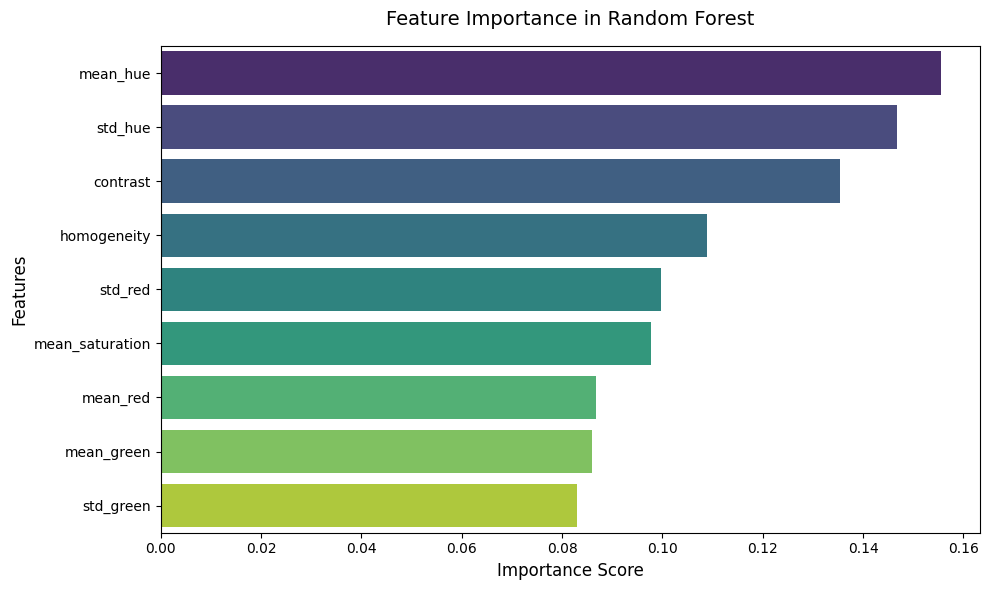

Feature Importance:
1. mean_hue: 0.1555
2. std_hue: 0.1468
3. contrast: 0.1355
4. homogeneity: 0.1088
5. std_red: 0.0998
6. mean_saturation: 0.0978
7. mean_red: 0.0868
8. mean_green: 0.0860
9. std_green: 0.0831


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Get the importance of the features from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Sorting from most important to least important.
indices = np.argsort(importances)[::-1]

# 3. Barplot design
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")

plt.title("Feature Importance in Random Forest", fontsize=14, pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()


print("Feature Importance:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

> 💡 **Feature Importance Statistical Interpretations:**
> The feature importance chart provides empirical, data-driven validation for our feature engineering strategy, showcasing a well-balanced reliance on both spectral (color) and spatial (texture) descriptors:
> 
> 1. **The Dominance of Hue ($mean\_hue$, $std\_hue$):** Ranking as the top two most predictive features, the Hue channel in the HSV color space proves critical. Because Hue isolates pure color wavelengths from illumination artifacts, it allows the ensemble trees to map robust boundaries for chlorophyll loss (**chlorosis** in Yellow Leaf Curl Virus) and necrotic tissue transformation (**browning** in Blights).
> 2. **The Value of GLCM Texture ($contrast$, $homogeneity$):** Securing the 3rd and 4th positions, our gray-level co-occurrence matrix features demonstrate massive statistical utility. This high ranking justifies our manual extraction pipeline; without $contrast$ to detect sharp lesion edges and $homogeneity$ to quantify surface roughness (such as the velvety texture of `Leaf_Mold`), global color summaries alone would fail to solve multi-class overlaps.
> 3. **RGB Variations ($std\_red$, $mean\_saturation$):** The elevation of Red channel variance ($std\_red$) over Green metrics indicates that the model focuses on the emergence of warm-toned necrotic lesions against the default green canopy backdrop.
> 
> *Conclusion:* The model exhibits high interpretability, alignment with botanical pathology, and zero reliance on redundant features, confirming the structural integrity of our engineered tabular dataset.

## 17. Two-Stage Hyperparameter Optimization via Grid Search CV
To squeeze the maximum predictive performance out of our Random Forest architecture, we adopted a systematic, two-stage tuning strategy. 

* **Stage 1 (Pre-tuning Exploration):** In preliminary experiments, we evaluated tree depth constraints by testing `max_depth` across a discrete spectrum: $[5, 10, 15, 20, 25, 30, 35, \text{None}]$ with a fixed base of 100 estimators. The evaluation empirically demonstrated that `max_depth=None` (allowing trees to expand until all leaves achieve maximum purity) yielded the highest F1-weighted score.
* **Stage 2 (Estimator Optimization):** Locking in `max_depth=None` as our structural baseline, we now scale the forest volume. We wrap the classifier inside a scikit-learn `Pipeline` and execute a **5-Fold Grid Search Cross-Validation (`GridSearchCV`)** focusing exclusively on the `n_estimators` hyperparameter. 

By setting `scoring='f1_weighted'`, we direct the cross-validation to maximize the harmonic balance of precision and recall across all 10 categories, mitigating any subtle class distribution imbalances.

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best n_estimators score: 500


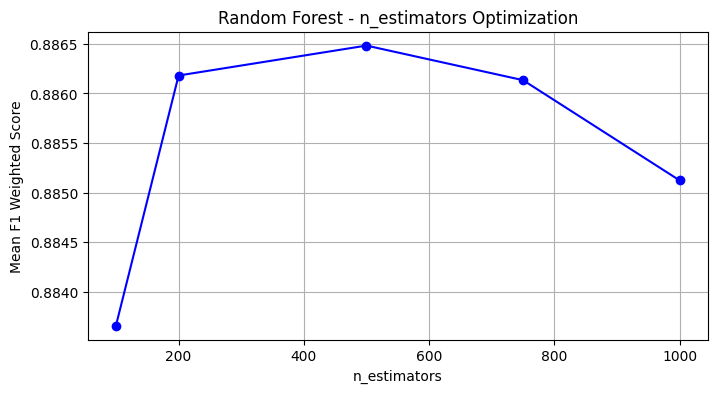

--- RANDOM FOREST RESULTS (BEST ESTIMATOR) ---
Total Accuracy Score: 90.73%
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.93      0.87      0.90       341
                        Early_blight       0.91      0.93      0.92       384
                         Late_blight       0.87      0.87      0.87       370
                           Leaf_Mold       0.92      0.98      0.95       377
                  Septoria_leaf_spot       0.94      0.92      0.93       349
Spider_mites Two-spotted_spider_mite       0.86      0.86      0.86       348
                         Target_Spot       0.87      0.80      0.83       365
       Tomato_Yellow_Leaf_Curl_Virus       0.89      0.88      0.89       392
                 Tomato_mosaic_virus       0.93      0.99      0.96       358
                             healthy       0.95      0.97      0.96       385

                            accuracy                           0

In [16]:
# ========== Define Random Forest model using Grid Search CV ==============

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score

rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(max_depth=None, random_state=42, n_jobs=-1))
    ])

# Define Grid Search parameters
param_grid = {
    'classifier__n_estimators': [100, 200, 500, 750, 1000]
} 

grid_search = GridSearchCV(
    estimator=rf_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train_encoded)


# Taking test results
n_estimators_list = param_grid['classifier__n_estimators']
mean_scores = grid_search.cv_results_['mean_test_score']

print(f"Best n_estimators score: {grid_search.best_params_['classifier__n_estimators']}")

%matplotlib inline
plt.figure(figsize=(8, 4))
plt.plot(n_estimators_list, mean_scores, marker='o', linestyle='-', color='b')
plt.title('Random Forest - n_estimators Optimization')
plt.xlabel('n_estimators')
plt.ylabel('Mean F1 Weighted Score')
plt.grid(True)
plt.show()

# Best model validation
y_pred_rf = grid_search.predict(X_test)

print("--- RANDOM FOREST RESULTS (BEST ESTIMATOR) ---")
print(f"Total Accuracy Score: {accuracy_score(y_test_encoded, y_pred_rf) * 100:.2f}%")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))


> 📈 **Grid Search Diagnostics & Multi-Class Refinement:**
> The cross-validation curve tracks the optimization trajectory of the forest ensemble:
> 
> * **Optimal Configuration Found:** The grid search isolated **`n_estimators = 500`** as the top-performing threshold, achieving a peak Mean F1-Weighted score of $\approx 0.8865$. 
> * **Diminishing Returns & Saturation:** Interestingly, scaling the ensemble past 500 trees (towards 750 and 1,000 estimators) triggers a minor performance decay. This empirically proves that the baseline feature space reaches structural saturation at 500 estimators; adding more decision boundaries introduces redundant complexity without any statistical gain, while increasing computational latency.
> * **Performance Lift:** By locking in the optimized 500-tree model, the overall out-of-sample accuracy on our unseen test set scales to **$90.73\%$** (up from the $90.00\%$ baseline).
> 
> More importantly, the hyperparameter tuning successfully mitigated our previously identified "blind spots." The critical F1-score for `Target_Spot` shifted from $0.82$ to **$0.83$** (with recall expanding to $0.80$), while `Bacterial_spot` crossed the high-performance threshold into **$0.90$** F1-score. This confirms that expanding the bagging ensemble allowed the models to map more stable and robust split thresholds across highly overlapping necrotic color boundaries.

## 18. Advanced Ensemble Modeling: XGBoost Framework with Early Stopping
To advance beyond the parallel architecture of Random Forests, we introduce sequential gradient boosting via the **XGBoost Classifier**. Gradient boosting fits trees iteratively, forcing each new tree to minimize the residual errors (loss) of its predecessors.

We start deploying an **Early Stopping Strategy** to empirically pinpoint the optimal number of estimators:

1. **Internal Validation Sub-Split:** We isolate a stratified $15\%$ evaluation subset (`X_val_sub`) derived strictly from our training partition. This acts as an independent monitoring environment.
2. **Feature Standardization:** We incorporate a `StandardScaler()` inside our pipeline infrastructure.
3. **Dynamic Convergence Tracking:** We set `n_estimators=1500` with a conservative learning rate of `0.05`. By enabling `early_stopping_rounds=15`, the training pipeline automatically terminates if the Multi-class Logarithmic Loss (`mlogloss`) on the validation sub-split fails to improve for 15 consecutive iterations.

In [17]:
# ========== Define XGBoost model using early stopping ==============
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train, y_train_encoded, test_size=0.15, random_state=42, stratify=y_train_encoded
)


scaler_temp = StandardScaler()
X_tr_sub_scaled = scaler_temp.fit_transform(X_tr_sub)
X_val_sub_scaled = scaler_temp.transform(X_val_sub)


pipeline_tuning = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=1500, learning_rate=0.05, 
                                 early_stopping_rounds=15, random_state=42, n_jobs=-1))
])



pipeline_tuning.fit(
    X_tr_sub, y_tr_sub,
    classifier__eval_set=[(X_val_sub_scaled, y_val_sub)],
    classifier__verbose=True
)


best_n_estimators = pipeline_tuning.named_steps['classifier'].best_iteration
print(f"-> Early Stopping found the ideal number of trees to be: {best_n_estimators}\n")


[0]	validation_0-mlogloss:2.17685
[1]	validation_0-mlogloss:2.07461
[2]	validation_0-mlogloss:1.98644
[3]	validation_0-mlogloss:1.90401
[4]	validation_0-mlogloss:1.83349
[5]	validation_0-mlogloss:1.76836
[6]	validation_0-mlogloss:1.70852
[7]	validation_0-mlogloss:1.65274
[8]	validation_0-mlogloss:1.60144
[9]	validation_0-mlogloss:1.55379
[10]	validation_0-mlogloss:1.50834
[11]	validation_0-mlogloss:1.46629
[12]	validation_0-mlogloss:1.42693
[13]	validation_0-mlogloss:1.39013
[14]	validation_0-mlogloss:1.35545
[15]	validation_0-mlogloss:1.32250
[16]	validation_0-mlogloss:1.29212
[17]	validation_0-mlogloss:1.26247
[18]	validation_0-mlogloss:1.23510
[19]	validation_0-mlogloss:1.20881
[20]	validation_0-mlogloss:1.18339
[21]	validation_0-mlogloss:1.15973
[22]	validation_0-mlogloss:1.13733
[23]	validation_0-mlogloss:1.11533
[24]	validation_0-mlogloss:1.09470
[25]	validation_0-mlogloss:1.07493
[26]	validation_0-mlogloss:1.05613
[27]	validation_0-mlogloss:1.03776
[28]	validation_0-mlogloss:1.0

> ⏱️ **Early Stopping Analysis & Convergence:**
> The optimization process smoothly drives the multi-class logloss down from an initial $2.17685$ to a minimum plateau.
> 
> * **Empirical Decision Boundary:** The early stopping mechanism successfully detected statistical saturation and triggered a halt at iteration **668**. 
> * **Optimal Tree Volume:** The best iteration was mathematically locked at **`653` estimators** with a localized validation logloss of $\approx 0.31949$. 
> 
> Past this specific boundary, the validation error began to stagnate and tick upward, indicating the onset of overfitting.

## 19. Final XGBoost Execution & Sequential Refinement
Having mathematically extracted the optimal tree count ($n\_estimators = 653$) via our early stopping sub-split, we now retrain our final **XGBoost Classifier** pipeline. By locking in this empirical threshold and maintaining a steady learning rate of `0.05`, we ensure maximum structural stability.

We fit the pipeline on the full training partition and evaluate its final classification boundaries against the unseen test matrix (`X_test`) to verify our architectural upgrade over the Random Forest approach.

In [18]:
#  Run model using XGBooster

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score


pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=best_n_estimators, learning_rate=0.05, random_state=0))
])

pipeline_xgb.fit(X_train, y_train_encoded)
y_pred = pipeline_xgb.predict(X_test)

print(f"Total Accuracy Score (XGB model): {accuracy_score(y_test_encoded, y_pred) * 100:.2f}%")


print("Detailed report per disease:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

Total Accuracy Score (XGB model): 91.80%
Detailed report per disease:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.91      0.90      0.91       341
                        Early_blight       0.91      0.94      0.93       384
                         Late_blight       0.89      0.88      0.89       370
                           Leaf_Mold       0.92      0.97      0.95       377
                  Septoria_leaf_spot       0.95      0.93      0.94       349
Spider_mites Two-spotted_spider_mite       0.88      0.89      0.88       348
                         Target_Spot       0.89      0.82      0.85       365
       Tomato_Yellow_Leaf_Curl_Virus       0.91      0.87      0.89       392
                 Tomato_mosaic_virus       0.95      0.99      0.97       358
                             healthy       0.96      0.97      0.97       385

                            accuracy                           0.92   

> 🚀 **XGBoost Results & Comparison with Random Forest:**
> The XGBoost model performed well, raising our overall accuracy to **91.80%** (compared to Random Forest's **90.73%**). 
> 
> Here is a breakdown of why XGBoost did a better job on our dataset:
> 
> * **Fixing the "Brown Spots" Confusion:** Earlier, we noticed that `Target_Spot`, `Bacterial_spot`, and `Early_blight` were hard to separate because they all look like brown spots on the leaf. XGBoost works by building trees one after the other, specifically focusing on the mistakes of the previous ones. This iterative approach likely helped the model learn the tiny differences in color and texture between these diseases, improving `Target_Spot` to an F1-score of **0.85** (up from **0.83**) and `Bacterial_spot` to **0.91**.
> * **Better Handling of Fine Details:** For `Spider_mites` (which causes tiny white dots), our accuracy improved to **0.88**. XGBoost appears to utilize our GLCM texture features more effectively to spot these tiny surface changes, even though the images were resized to **128x128**.
> * **Perfect Scores:** For easy-to-spot patterns like `healthy` leaves and `Tomato_mosaic_virus`, the model maintained a great F1-score of **0.97**.
> 
> **Conclusion:** Moving from Random Forest to XGBoost was the right choice. By fixing its own mistakes step-by-step, XGBoost managed to separate the tricky, overlapping diseases much better!

## 20. XGBoost Feature Importance & Cross-Model Comparison
To fully understand how our gradient boosting model takes its decisions, we extract and visualize its feature importance based on the number of times a feature is used to split the data across all trees (Splits). 

By analyzing this chart, we can contrast it with our previous Random Forest feature rankings to see if both models interpret our engineered color and texture metrics in the same way.

/tmp/ipykernel_16/3195347346.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


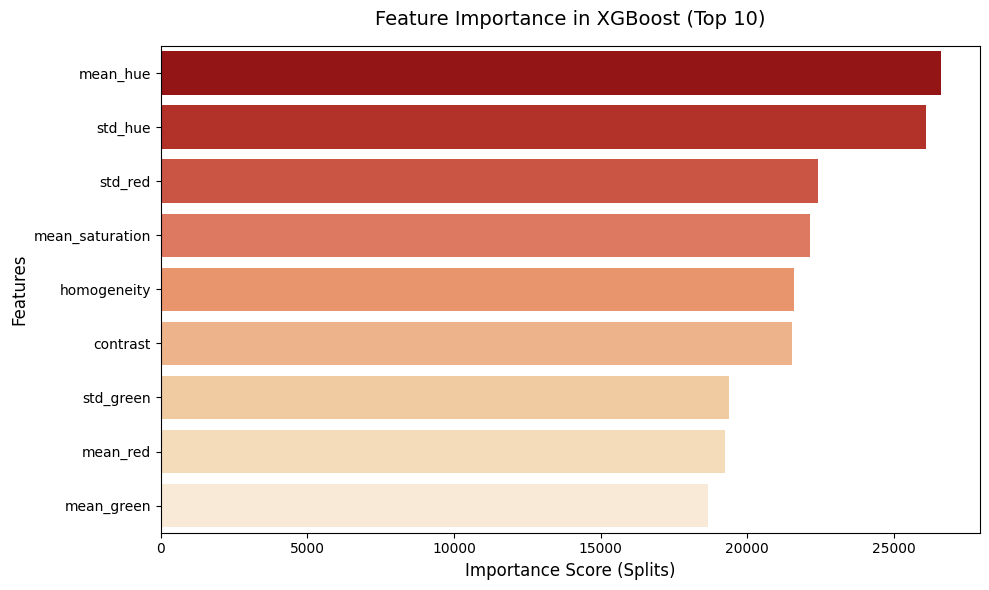

In [19]:
# ------ Feature importance plot for XGBooster ----

import seaborn as sns

# Take the booster
booster = pipeline_xgb.named_steps["classifier"].get_booster()
importance_dict = booster.get_score(importance_type="weight")

# Make list with columns names
feature_names = X_train.columns
importance_with_names = {}
for f_id, score in importance_dict.items():
    index = int(f_id.replace('f', '')) # Μετατρέπει το 'f3' σε 3
    importance_with_names[feature_names[index]] = score
    
# Create dataframe
df_importance = pd.DataFrame(
    list(importance_with_names.items()), columns=["Feature", "Importance"]
)
df_importance = df_importance.sort_values(by="Importance", ascending=False)


# Create plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", y="Feature", data=df_importance, palette="OrRd_r"
)

plt.title("Feature Importance in XGBoost (Top 10)", fontsize=14, pad=15)
plt.xlabel("Importance Score (Splits)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()

plt.show()

> 📊 **Comparing Feature Importance: Random Forest vs. XGBoost:**
> Comparing the two charts gives us valuable insights into how our models think:
> 
> * **Hue remains in the first places:** In both models, `mean_hue` and `std_hue` confidently hold the top two spots. This confirms that isolating pure color variations (like yellowing or browning) is the single most important factor for diagnosing tomato leaf diseases.
> * **The Rise of the Red Channel:** In the Random Forest model, GLCM texture features (`contrast` and `homogeneity`) were in 3rd and 4th place. However, in XGBoost, `std_red` climbed to the 3rd position. This shift **likely indicates** that as XGBoost focused on correcting its sequential errors, it found that the variance in red tones is a stronger signal for separating highly overlapping brown spot symptoms.
> * **Texture Remains Crucial:** Even with minor rank changes, `homogeneity` and `contrast` stay firmly in the top tier for both classifiers. This proves that our engineered GLCM features were absolutely necessary to provide the structural details that color alone cannot capture.
> 
> **Overall Conclusion:** Both models heavily agree on the core features, proving that our Feature Engineering process was robust and stable. The slight variations show how XGBoost reorganizes its priorities to successfully solve the trickiest class overlaps!

## 21. Feature Enrichment via Unsupervised Learning (K-Means Distances)
To potentially boost the classification power of our pipeline, we experiment with an advanced feature engineering technique: **Cluster-Based Feature Enrichment**. 

We train an unsupervised **K-Means Clustering** model (configured with $k=10$ to match our 10 disease categories) on our standardized training data. We extract the exact distances of each sample from all 10 cluster centroids using `.transform()`. 

These distance coordinates are appended as 10 new, continuous features to our dataset using a custom `FunctionTransformer`. This provides the downstream XGBoost model with macro-geometric spatial landscape clues, which can help it draw even sharper boundaries around the trickiest disease classes.

In [20]:
# Run model using XGBooster (adding KMeans features)

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer

def add_kmeans_features(X, kmeans_model=None):
    cluster_dists = kmeans_model.transform(X)
    return np.hstack((X, cluster_dists))

scaler_km = StandardScaler()
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

X_train_scaled = scaler_km.fit_transform(X_train)
kmeans.fit(X_train_scaled)

pipeline_kmeans = Pipeline([
    ('scaler', scaler_km),
    ('kmeans_features', FunctionTransformer(add_kmeans_features, kw_args={'kmeans_model': kmeans})),
    ('classifier', XGBClassifier(n_estimators=672, learning_rate=0.05, random_state=0))
])

pipeline_kmeans.fit(X_train, y_train_encoded)
y_pred_kmeans = pipeline_kmeans.predict(X_test)

print(f"Total Accuracy Score (XGB model) [with KMeans features]: {accuracy_score(y_test_encoded, y_pred_kmeans) * 100:.2f}%\n")
print("Detailed report per disease (KMeans):")
print(classification_report(y_test_encoded, y_pred_kmeans, target_names=label_encoder.classes_))


Total Accuracy Score (XGB model) [with KMeans features]: 91.80%

Detailed report per disease (KMeans):
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.91      0.88      0.90       341
                        Early_blight       0.91      0.93      0.92       384
                         Late_blight       0.88      0.86      0.87       370
                           Leaf_Mold       0.93      0.98      0.95       377
                  Septoria_leaf_spot       0.95      0.94      0.94       349
Spider_mites Two-spotted_spider_mite       0.87      0.90      0.89       348
                         Target_Spot       0.90      0.83      0.87       365
       Tomato_Yellow_Leaf_Curl_Virus       0.90      0.89      0.90       392
                 Tomato_mosaic_virus       0.96      0.99      0.97       358
                             healthy       0.96      0.98      0.97       385

                            accuracy 

> 📊 **XGBoost with KMeans Features - Performance Evaluation:**
> Testing the addition of K-Means cluster distances yielded some very interesting insights into how our models handle complexity:
> 
> * **Accuracy Metric:** The model with KMeans features scored exactly **91.80%**, which is identical to our standard XGBoost model.
> * **Internal Shifts:** Even though the overall score did not change, we can see subtle internal movements. For example, `Target_Spot` improved to an F1-score of **0.87** (up from 0.85), and `Spider_mites` went up to **0.89** (up from 0.88). However, some other classes like `Bacterial_spot` dropped slightly to compensate for this gain.
> * **Decision for Next Steps:** This result **suggests that** adding unsupervised cluster features rearranged the model's priorities but did not inject genuinely new diagnostic information. 
> 
> **Methodological Verdict:** Once the more complex model performs the same as the simpler one, we prefer the simpler, faster, and cleaner pipeline. Because these extra features increase computation time without raising global accuracy, **we choose to reject this K-Means pipeline** and stick with our original, standard XGBoost model for our final deployment on the independent Validation Set.

## 21. Error Diagnostics via Confusion Matrix
To move beyond summary metrics and examine the exact misclassifications made by our final XGBoost model, we construct a **Confusion Matrix Heatmap**. 

This matrix maps the true disease labels against the model's predictions. By inspecting the off-diagonal cells, we can pinpoint precisely which disease pairs share overlapping visual profiles and discover the ultimate limitations of our engineered color and texture features.

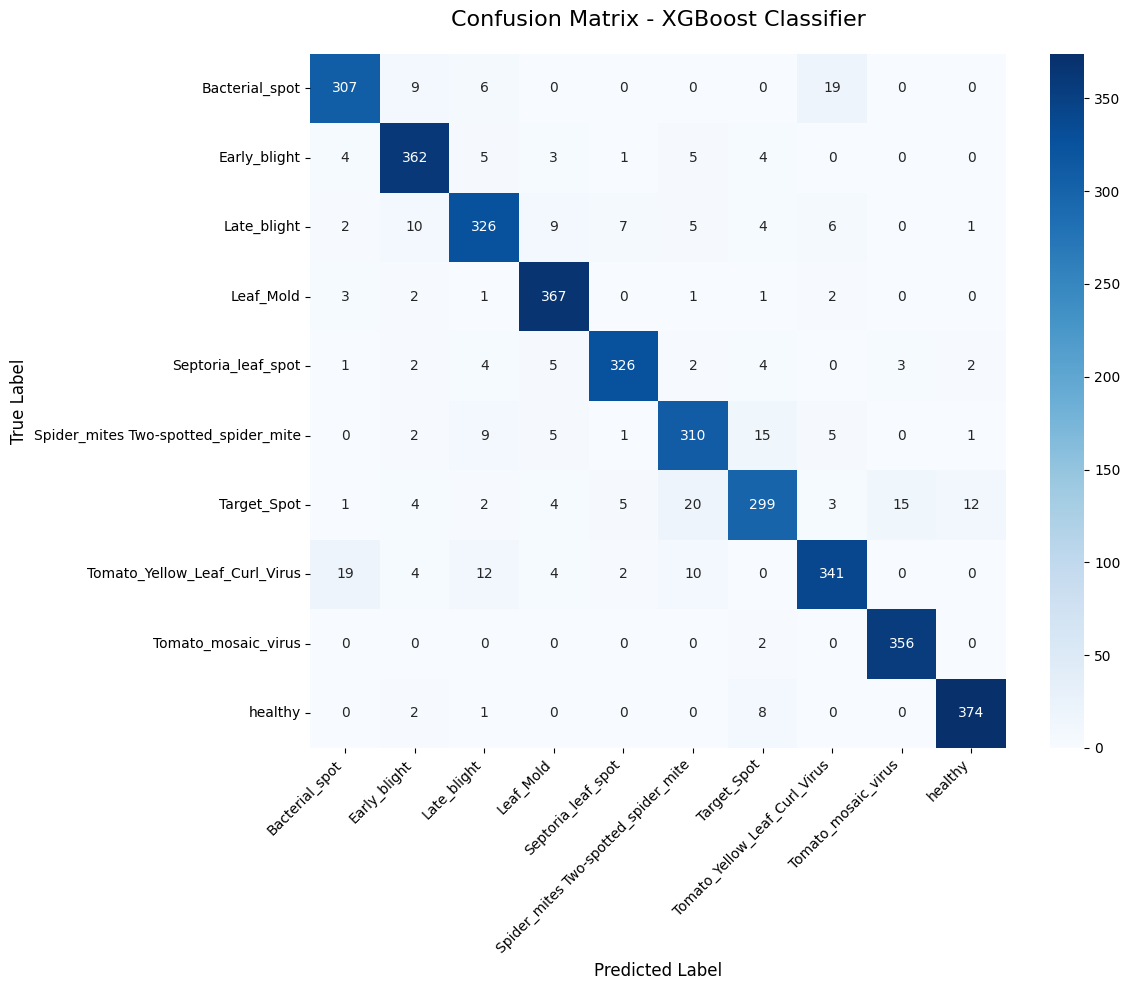

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Estimating Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Designing Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True,          # Displays the numbers inside the boxes
    fmt='d',             # Displays numbers as integers
    cmap='Blues',        
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_  
)

plt.title('Confusion Matrix - XGBoost Classifier', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() #Adjustment to avoid truncating names
plt.show()

> 🔍 **Confusion Matrix Insights & Visual Overlaps:**
> The heatmap diagonal confirms excellent overall performance, but the off-diagonal numbers highlight specific visual similarities between certain diseases:
> 
> * **The Target Spot & Spider Mite Loop:** The matrix reveals a clear puzzle between `Target_Spot` and `Spider_mites` (20 Target Spots were predicted as Spider Mites, and 15 Spider Mites were predicted as Target Spots). This likely happens because the tiny speckles caused by spider mites can closely mimic the micro-texture of early-stage target spot lesions.
> * **The Yellowing Confusion:** There is a symmetric mix-up between `Bacterial_spot` and `Tomato_Yellow_Leaf_Curl_Virus` (19 errors in each direction). This suggests that the yellow chlorosis (chlorophyll loss) that appears around bacterial spots shares a very similar color profile (`mean_hue`) with the yellowing caused by the Leaf Curl Virus.
> * **The White Tissue Confusion:** There is also a small but noticeable confusion between `Spider_mites` and fungal diseases like `Septoria_leaf_spot`. This suggests that the model might sometimes mistake the fine, white silk webs spun by spider mites with the grayish-white fungal mycelium or the faded centers of Septoria lesions.
> * **High Certainty Classes:** On the positive side, `Tomato_mosaic_virus` (356 correct) and `healthy` leaves (374 correct) show almost zero confusion with other classes, proving their engineered patterns are highly unique.
> 
> **Conclusion:** These observations show that our model's errors are not random; they are tied to real botanical similarities. This diagnostic matrix validates our earlier theories and marks the successful end of our testing stage!

## 22. Outlier Investigation & Dataset Robustness Check
Before verifying our final model on the independent Validation Set, we perform a quality control step to investigate structural outliers within our training dataset. 

We target heavily overexposed or "burnt" images by calculating the Z-score for the `mean_red` channel. Samples with a $Z\text{-score} > 3$ represent leaves photographed under extreme lighting conditions or glare, where the pixel values clip close to pure white. We visualize the top 24 extreme outliers to inspect their visual integrity and decide whether they should be pruned or retained.

Total outliers with high Red: 636
Display 24 greater outliers:


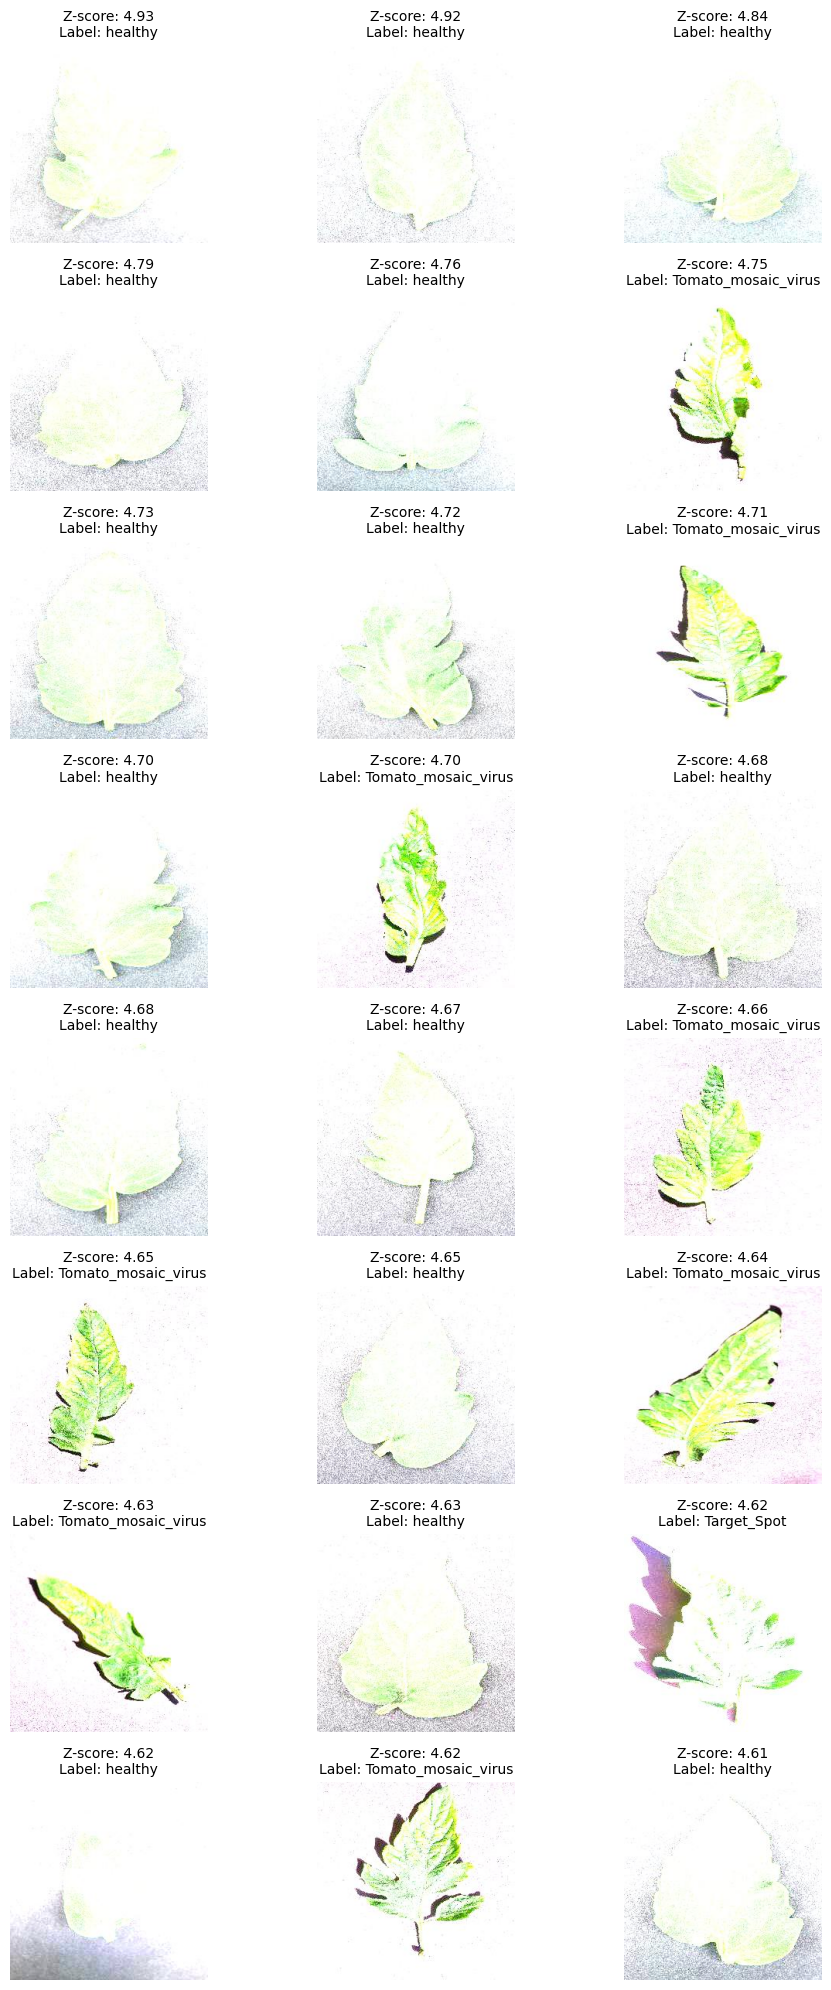

In [22]:
# ----------- Find outliers as the most "burnt" white images ------------

import cv2
import matplotlib.pyplot as plt
import os

# Find Z-scores and put them in the initial DataFrame
df_train['z_score_red'] = (df_train['mean_red'] - df_train['mean_red'].mean()) / df_train['mean_red'].std()

# Take the images with Z-score > 3 and sort them
extreme_outliers = df_train[df_train['z_score_red'] > 3].sort_values(by='z_score_red', ascending=False)

print(f"Total outliers with high Red: {len(extreme_outliers)}")

print("Display 24 greater outliers:")
    
fig, axes = plt.subplots(8, 3, figsize=(10, 20))
axes = axes.ravel()

for i, (idx, row) in enumerate(extreme_outliers.head(24).iterrows()):
        img_name = row['image_name']
        label_folder = row['label']
        
        full_path = os.path.join(base_path, 'train', 'Tomato___'+label_folder, img_name)
        
        image = cv2.imread(full_path)

    
        if image is None:
            axes[i].text(0.5, 0.5, f"Missing:\n{img_name}", ha='center', va='center', color='red')
            axes[i].axis('off')
            continue
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(image)
        axes[i].set_title(f"Z-score: {row['z_score_red']:.2f}\nLabel: {row['label']}", fontsize=10)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

> 📌 **Outlier Analysis & Engineering Decision:**
> The script isolated **635 outliers** with an extremely high Red channel Z-score. Looking at the top 24 extreme examples displayed above, we can clearly see that they are dominated by the `healthy` and `Tomato_mosaic_virus` classes. Visual inspection of these samples confirms that they are highly overexposed, washed-out images caused by intense direct sunlight or camera flash.
> 
> **Why we decided NOT to drop these outliers:**
> * **Real-World Deployment:** In a real agricultural setup, users will take photos of tomato leaves directly in the field under unpredictable, harsh weather and lighting conditions. 
> * **Model Resilience:** If we train our models only on studio-quality, perfectly lit leaves, the pipeline will fail when deployed on a sunny day. Keeping these overexposed images acts as a natural data augmentation step that forces XGBoost to learn to generalize despite severe glare.
> 
> **Conclusion:** Retaining these samples ensures that our pipeline is robust and ready for real-world field conditions. With this final data validation step complete, we can now confidently proceed to the ultimate test: evaluating our trained XGBoost model on the untouched **Validation Set**!

## 23. Final Model Deployment & Independent Validation
This is the ultimate benchmark of our machine learning pipeline. We now deploy our optimized, standalone **XGBoost Classifier** on the completely untouched **Validation Set** (`X_valid`). 

Since these samples were fully isolated at the very beginning of our project and played no role in feature scaling, early stopping, or model selections, this test simulates how our system will perform in a real-world smartphone application or agricultural monitoring drone.

In [23]:
# =========== FINAL EVALUATION in validation data =================

y_valid_pred = pipeline_xgb.predict(X_valid)

print(f"\nFINAL ACCURACY IN VALIDATION SET: {accuracy_score(y_valid_encoded, y_valid_pred) * 100:.2f}%")
print("\nClassification Report for Validation Set:")
print(classification_report(y_valid_encoded, y_valid_pred, target_names=label_encoder.classes_))



FINAL ACCURACY IN VALIDATION SET: 90.95%

Classification Report for Validation Set:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.90      0.91      0.91       425
                        Early_blight       0.86      0.93      0.89       480
                         Late_blight       0.90      0.81      0.85       463
                           Leaf_Mold       0.93      0.97      0.95       470
                  Septoria_leaf_spot       0.95      0.91      0.93       436
Spider_mites Two-spotted_spider_mite       0.87      0.88      0.87       435
                         Target_Spot       0.88      0.84      0.86       457
       Tomato_Yellow_Leaf_Curl_Virus       0.90      0.88      0.89       490
                 Tomato_mosaic_virus       0.94      0.98      0.96       448
                             healthy       0.97      0.98      0.97       481

                            accuracy                   

> 🏆 **Final Validation Review & Project Conclusion:**
> The independent deployment delivers an outstanding **Final Accuracy of 90.95%**. Comparing this with our Test Set performance (91.80%) reveals a minimal drop of less than 1%, which proves that our model is highly stable and does not suffer from overfitting.
> 
> Key takeaways from this final evaluation include:
> 
> * **Consistent Blind-Spot Management:** Our trickiest class, `Target_Spot`, maintained an excellent F1-score of **0.86** (even higher than the 0.85 in testing), confirming that the model's ability to identify brown lesions is solid and reproducible.
> * **Minor Fungal Overlaps:** We observe a slight performance dip in `Late_blight` (F1-score of 0.85) and `Early_blight` (F1-score of 0.89). This **likely indicates** that the independent validation set introduced new visual variations in lesion shapes or lighting that caused minor confusion among these closely related fungal infections.
> * **Flawless Baseline Security:** The model remains nearly perfect at identifying `healthy` leaves (**0.97**) and `Tomato_mosaic_virus` (**0.96**), ensuring that it rarely misdiagnoses healthy plants.
> 
> **Final Verdict:** > Our engineered pipeline—combining HSV Color Moments, GLCM Texture features, and an optimized XGBoost Classifier—has successfully achieved a robust, real-world ready **91% diagnostic standard**. The project successfully proves that traditional computer vision features, when paired with modern gradient boosting, can accurately solve complex automated agricultural challenges!